### Individual glacier-based elevation change result.
#### note: the glacier area larger than 4 km2 is selected.


In [13]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np 
from utils.imgs_in_extent import imgs_in_extent
from glob import glob
from utils.ransac_fitting import ransac_fitting
import rasterio as rio
from rasterio.merge import merge
from rasterio.mask import mask
import warnings
import pandas as pd
from shapely import buffer, Polygon
from shapely.geometry import box



In [14]:
path_rgi60_setp = 'data/land-cover/rgi60/rgi60_setp.shp'
dir_dif_map = 'data/aster-stereo/tiles-dif-map'
paths_dif_map = glob(dir_dif_map + '/tile_??_??.tif')
path_result_glacier = 'data/ele-change-result/ele_change_glaciers.pkl'
path_srtm = 'data/dem-data/srtm-c/SRTMGL1_E.tif'


In [15]:
rgi60_setp = gpd.read_file(path_rgi60_setp)
id  = np.where(rgi60_setp['RGIId']=='RGI60-15.11962')[0]
rgi60_setp_sel = rgi60_setp.iloc[id]
rgi60_setp_sel.head()


,RGIId,Area,CenLon,CenLat,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,geometry
6623,RGI60-15.11962,0.23,96.902,29.303,5139,5375,5207,16.6,19,834,"POLYGON ((96.90025 29.30036, 96.90010 29.30026..."


In [16]:
rgi_id = np.array(rgi60_setp_sel.RGIId)
area_glaciers = np.array(rgi60_setp_sel.Area)
x_years = np.arange(23)
years = np.array([str(year) for year in range(2000, 2023)])
years

array(['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022'],
      dtype='<U4')

In [17]:
rate_glaciers = []
dif_map_glaciers = []
ele_change_glaciers = []
ele_change_fitting_glaciers = []
srtm_glaciers_masked = []
## obtain the dif_maps of the glaicer reigon.
for i_gla in range(rgi60_setp_sel.shape[0]):
    # i_gla = 50
    print('i_gla:', i_gla)
    geo_gla = rgi60_setp_sel.iloc[i_gla]['geometry'] 
    bounds = geo_gla.bounds
    extent = [bounds[0], bounds[2], bounds[1], bounds[3]]
    dif_map_sel = imgs_in_extent(paths_img=paths_dif_map, extent=extent)  ## subset by specific glacier vector (produce subsets from different tiles.).
    print('number of selected dif_map:', len(dif_map_sel))
    # dif_map
    dif_map = rio.open(dif_map_sel[0])
    if len(dif_map_sel)>1:
        dif_map_mosaic, dif_map_mosaic_trans = merge(dif_map_sel)   ## mosaic subsets of dif_map to one glacier. 
        meta_mosaic = dif_map.meta.copy()
        meta_mosaic.update({'driver': 'GTiff',
                            'height': dif_map_mosaic.shape[1],
                            'width': dif_map_mosaic.shape[2],
                            'transform': dif_map_mosaic_trans,                       
                            })
        with rio.open('dif_map_mosaic.tif', 'w', **meta_mosaic) as m:
            m.write(dif_map_mosaic)
        dif_map = rio.open('dif_map_mosaic.tif')
    dif_map_gla_masked, dif_map_gla_masked_trans = mask(dif_map, [geo_gla], filled=False, crop=True)  ## mask out the non-glacier region
    dif_map_gla_masked = dif_map_gla_masked.filled(np.nan)
    ## srtm dem (masked the outer region of glacier/no masked the ...)
    srtm_dem = rio.open(path_srtm)
    srtm_dem_gla_masked, srtm_dem_gla_masked_trans = mask(srtm_dem, [geo_gla], filled=False, crop=True) ## mask out the non-glaicer region
    srtm_dem_gla_masked = srtm_dem_gla_masked.filled(np.nan)
    srtm_dem_gla_masked = np.reshape(srtm_dem_gla_masked, srtm_dem_gla_masked.shape[1:])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        dif_maps_gla_mean = np.nanmean(dif_map_gla_masked, axis=(1,2))  ## mean diference value of the specific glacier. 
    mean_filtered, mean_fitting, rate = ransac_fitting(x=x_years, y=dif_maps_gla_mean, thre_mask=50)
    print(rate)
    rate_glaciers.append(rate)
    dif_map_glaciers.append(dif_map_gla_masked)
    ele_change_glaciers.append(dif_maps_gla_mean)
    ele_change_fitting_glaciers.append(mean_fitting)
    srtm_glaciers_masked.append(srtm_dem_gla_masked)

if os.path.exists('dif_map_mosaic.tif'): os.remove('dif_map_mosaic.tif')



i_gla: 0
number of selected dif_map: 1
-0.20662102057395296


In [18]:
print(years[6:12])
print(dif_maps_gla_mean[6:12])


['2006' '2007' '2008' '2009' '2010' '2011']
[ -4.45019           nan  -4.80462   -11.450185   -7.2845798 -16.048162 ]


In [19]:
dif_maps_gla_mean[11]-dif_maps_gla_mean[6]


-11.597973

In [20]:
(dif_maps_gla_mean[10]-dif_maps_gla_mean[6])/4



-0.7085974216461182

In [21]:
mean_filtered, mean_fitting, rate = ransac_fitting(x=x_years[5:12], y=dif_maps_gla_mean[5:12], thre_mask=50)
rate


-2.3206789870011173

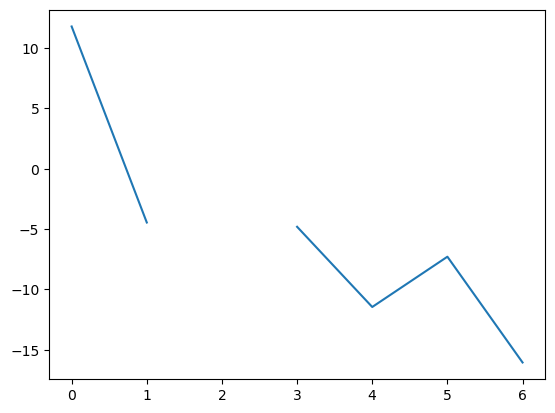

In [22]:
plt.plot(mean_filtered)



In [23]:
result_df = pd.DataFrame({'rgi_id': rgi_id,
                    'ele_change': ele_change_glaciers,
                    'ele_change_fitting': ele_change_fitting_glaciers,
                    'rate': rate_glaciers,
                    'gla_area':area_glaciers,
                    'dif_map': dif_map_glaciers,
                    'geometry':rgi60_setp_sel['geometry'],
                    'srtm_dem_masked': srtm_glaciers_masked,
                    'Zmin': rgi60_setp_sel['Zmin'],
                    'Zmax': rgi60_setp_sel['Zmax'],
                    'Zmed': rgi60_setp_sel['Zmed'],
                    'Slope': rgi60_setp_sel['Slope'],
                    'Aspect': rgi60_setp_sel['Aspect'],
                    'Lmax': rgi60_setp_sel['Lmax']
                   })
result_df.head()


,rgi_id,ele_change,ele_change_fitting,rate,gla_area,dif_map,geometry,srtm_dem_masked,Zmin,Zmax,Zmed,Slope,Aspect,Lmax
6623,RGI60-15.11962,"[nan, 0.04596315, nan, nan, nan, 11.792396, -4...","[-1.4519874760532852, -1.658608496627238, -1.8...",-0.206621,0.23,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","POLYGON ((96.90025 29.30036, 96.90010 29.30026...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",5139,5375,5207,16.6,19,834


### Write out

In [ ]:
# if os.path.exists(path_result_glacier): os.remove(path_result_glacier)
# result_df.to_pickle(path_result_glacier)

